# 1. Libraries

In [2]:
# Lets import the libraries for this data science project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 2. Load the data

In [4]:
# Loading the data
path = './Data/'
df = pd.read_csv(path + 'Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 3. Exploratory analysis

## 3.1. Descriptive analysis

In [7]:
# Lets get the initial descriptive analysis of all varaibles, including categories
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# Lets get descriptive statistics for categories
df.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [6]:
# Lets check the data types of the variables
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [9]:
# Check for NaN values in the dataset
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Cabin, Age and Embarked are the only columns containing null values. This means that they whould be either processed or eliminated when doing the ML model for causality. 

In [11]:
# Check for the % of NaN values in the dataset
df[["Age", "Cabin", "Embarked"]].isnull().sum() / df.shape[0] * 100

Age         19.865320
Cabin       77.104377
Embarked     0.224467
dtype: float64

This tells us that Cabin could be dropped for the ML model because most of it is NaN. For age we can use an imputer in the preprocessing phase. Embarked can also be processed adequatly since it doesn´t represent any of the data.

## 3.2. Histograms

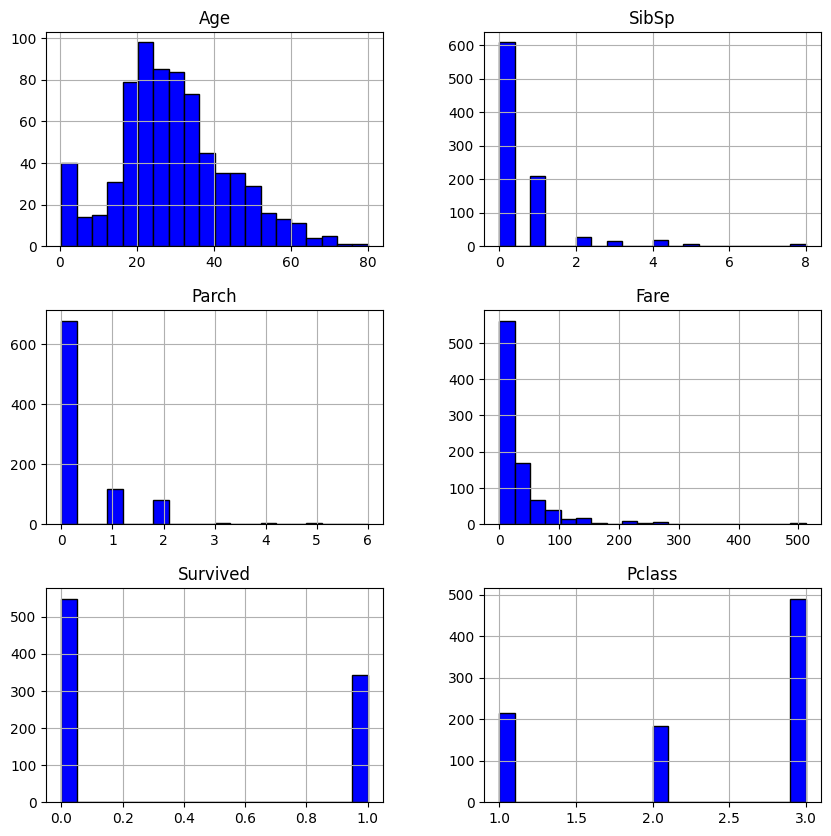

In [14]:
# Plot histograms for numerical variables
numerical_cols =['Age', 'SibSp', 'Parch', 'Fare', 'Survived', 'Pclass']
df[numerical_cols].hist(figsize=(10, 10), bins=20, color='blue', edgecolor='black')
plt.show()

At first sight, we can see that there is class imbalance in the survived column. However, lets explor this for the sex category. We are going to dive deeper in the sex category since we want to implement a Causal ML model for it.

## 3.3. Sex analysis

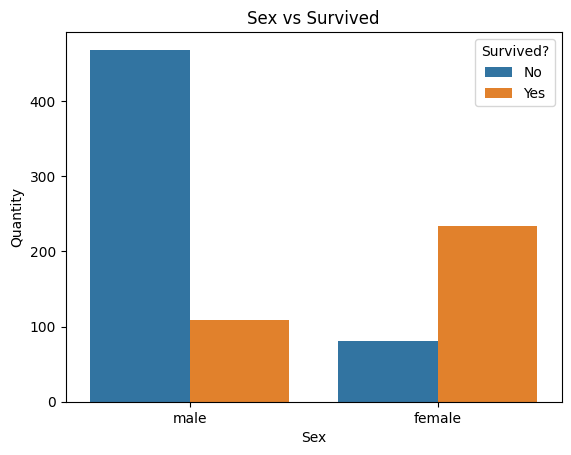

In [24]:
# Lets plot the distribution of Survived with respect to SEX using seaborn

sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Sex vs Survived')
plt.xlabel('Sex')
plt.ylabel('Quantity')
plt.legend(title='Survived?', labels=['No', 'Yes'])
plt.show()

Apparently, the class is unbalanced for either sex. Meaning that we can apply some sampling techniques in the future.

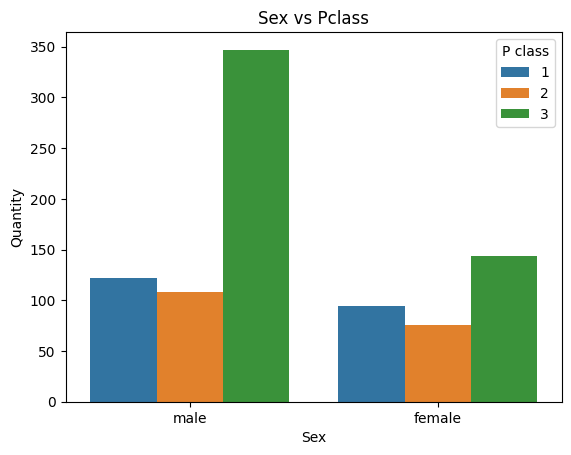

In [33]:
# Lets plot sex vs Pclass using seaborn

sns.countplot(data=df, x="Sex", hue="Pclass")
plt.title('Sex vs Pclass')
plt.xlabel('Sex')
plt.ylabel('Quantity')
plt.legend(title='P class', labels=[1,2,3])
plt.show()

There were more passengers in the 3rd class. This variable could be a deciding factor for those who survived. 